# IPL 2022 Capstone Project

**The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.**

**These are some of the important columns that we'll focus on for meaningful insights in this project.**

**column names: Variable Type**

**Loading the libraries and dataset**

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('IPL.csv')

In [5]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


**Basic Information**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [7]:
print(f'Your rows are {df.shape[0]} and columns are {df.shape[1]}')

Your rows are 74 and columns are 20


**Basic Questions**

**1. Which team won the most matches?**

Text(0.5, 1.0, 'Most match win by team')

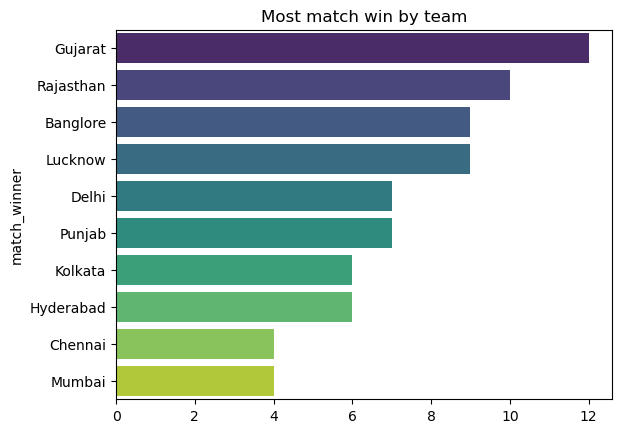

In [18]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index,x = match_wins.values, palette = 'viridis' )
plt.title('Most match win by team')

**2. Toss Decision Trends**

Text(0.5, 1.0, 'Toss decision trends')

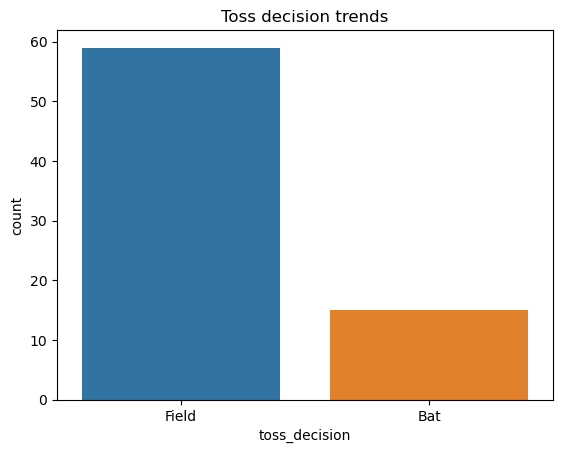

In [35]:
sns.countplot(x = df['toss_decision'], hue = df['toss_decision'])
plt.title('Toss decision trends')

**3. Toss Winner vs Match winner**

In [33]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

**4. How do teams win? (Runs vs Wickets)**

Text(0.5, 1.0, 'won_by')

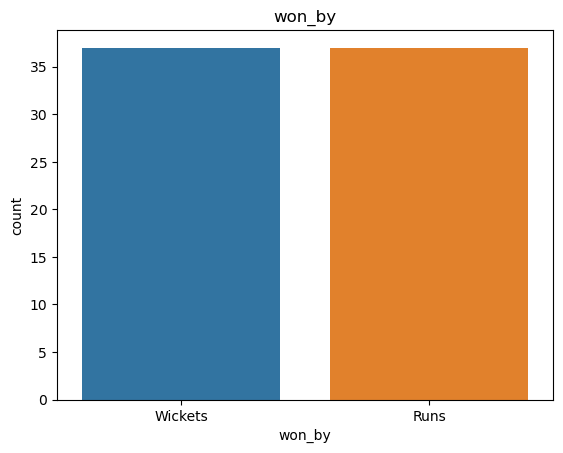

In [38]:
sns.countplot(x = df['won_by'], hue = df['won_by'])
plt.title('won_by')

**Key player performance**

**1. Most 'Player of the match' awards**

In [51]:
count = df['player_of_the_match'].value_counts().head(10)

Text(0.5, 0, 'No._of_time')

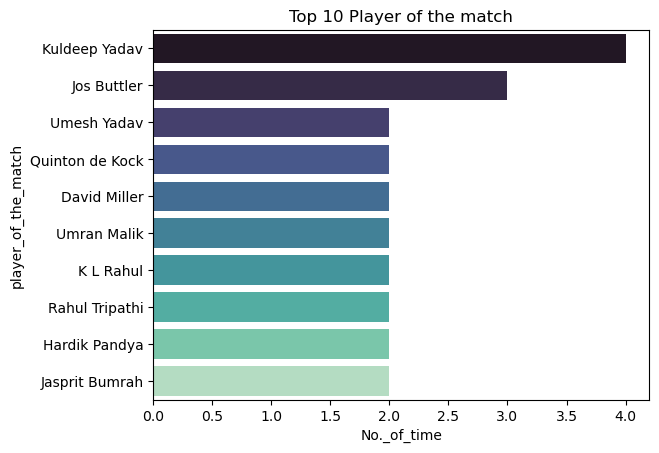

In [56]:
sns.barplot(x = count.values , y = count.index, palette = 'mako')
plt.title('Top 10 Player of the match')
plt.xlabel('No._of_time')

**2. Top 2 Scorers**

In [70]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

**3. Top 10 best bowling figure**

In [94]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
best_bowlers = df.groupby('best_bowling')['highest_wickets'].max().sort_values(ascending = False).head(10)
best_bowlers

best_bowling
Yuzvendra Chahal     5
Wanindu Hasaranga    5
Umran Malik          5
Jasprit Bumrah       5
Kuldeep Sen          4
Umesh Yadav          4
Shardul Takur        4
Rashid Khan          4
Odean Smith          4
Mukesh Choudhary     4
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

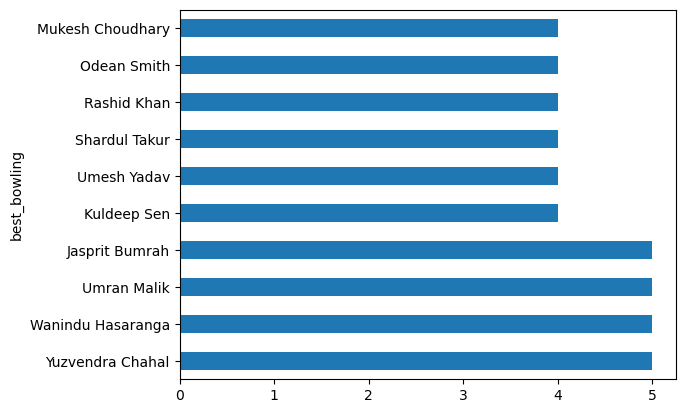

In [95]:
best_bowlers.plot(kind = 'barh')

**Venue Analysis**

**Most matches played by venue**

In [97]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

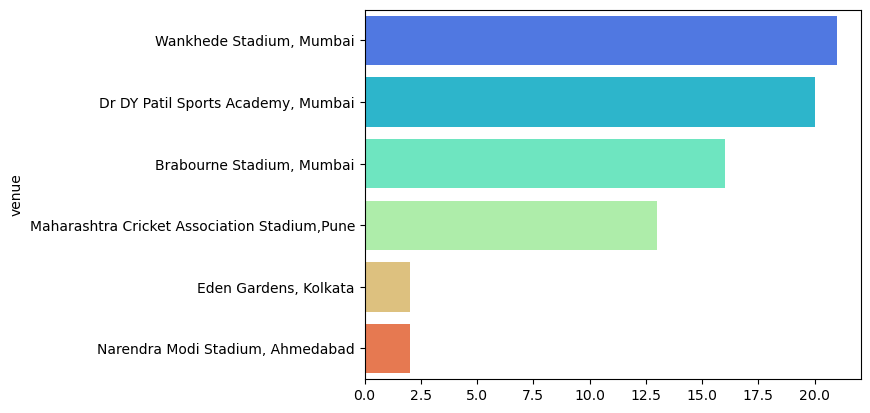

In [100]:
sns.barplot(y = venue_count.index , x = venue_count.values, palette ='rainbow' )

**Insight**

**1. Who won the highest margin by runs?**

In [113]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending = False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


**2. Which player has the highest individual score**

In [120]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


**3. Which bowler had the best bowling figure**

In [133]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
